# Household Behavior over the Life Cycle. Exam 2024.

## Setup

In [6]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Example: setup model instance, solve and simulate it.

In [7]:
from DynLaborModel import DynLaborModelClass
model = DynLaborModelClass()

model.solve()
model.simulate()

## Q2: Human capital depreciation shock
I have added the probability, $p_k=0,6$ and $\delta=0,2$ in DynLaborModel.py along with the necessary modifications. To implement this, I have included ``par.pk`` in the ``setup()`` function and updated the ``value_of_choice()`` function in the solution of the model. The depreciation rate is also included in the  ``setup()`` function as ``par.delta``.

I have also included a new uniform draw in the simulation of the model, stored in ``sim.delta_shock`` and used in the ``simulate()`` function to determine the transition of the human capital.


nesting check, max |diff| in mean hours: 8.224112765242708e-06


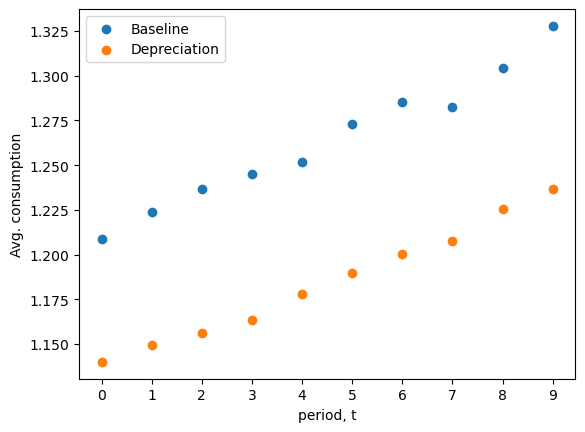

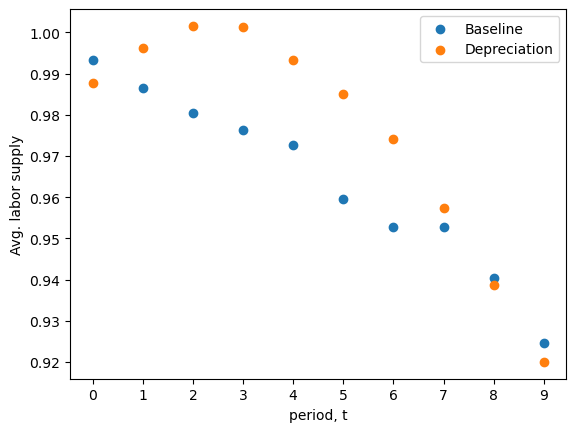

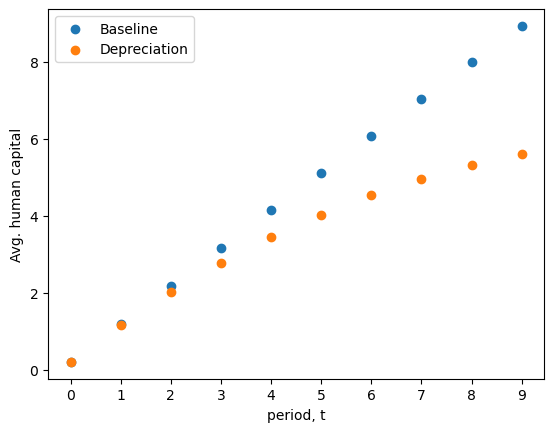

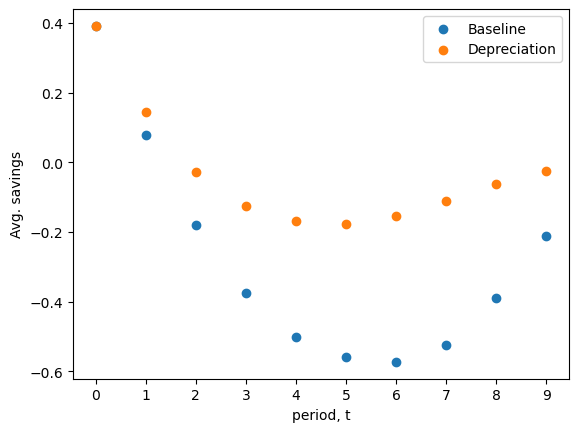

In [8]:
# baseline (depreciation switched off via delta = 0)
model_base = DynLaborModelClass(par={'delta':0.0, 'pk':0.6})
model_base.solve()
model_base.simulate()

# depreciation model
model_depr = DynLaborModelClass(par={'delta':0.2, 'pk':0.6})
model_depr.solve()
model_depr.simulate()

# nesting check (hint): pk = 0 should also reproduce the baseline
model_off = DynLaborModelClass(par={'delta':0.2, 'pk':0.0})
model_off.solve()
model_off.simulate()
print('nesting check, max |diff| in mean hours:',
      np.max(np.abs(np.mean(model_base.sim.h, axis=0) - np.mean(model_off.sim.h, axis=0))))

# plot comparison
labels = {'c':'consumption', 'h':'labor supply', 'k':'human capital', 'a':'savings'}
for var in ('c','h','k','a'):
    fig, ax = plt.subplots()
    ax.scatter(range(model_base.par.simT), np.mean(getattr(model_base.sim, var), axis=0), label='Baseline')
    ax.scatter(range(model_depr.par.simT), np.mean(getattr(model_depr.sim, var), axis=0), label='Depreciation')
    ax.legend()
    ax.set(xlabel='period, t', ylabel=f'Avg. {labels[var]}', xticks=range(model_base.par.simT))

## Q3: Tax rate on wealth
I modify the ``wealth_trans``and ``cons_last``functions. I add ``par.tau_a`` to the setup.
 

In [15]:
# baseline = Q2 model (depreciation on, tau_a = 0)
model_base = model_depr.copy()

# wealth-tax model: identical depreciation + shocks, just add the tax
model_tax = model_depr.copy()
model_tax.par.tau_a = 0.10
model_tax.solve()
model_tax.simulate()


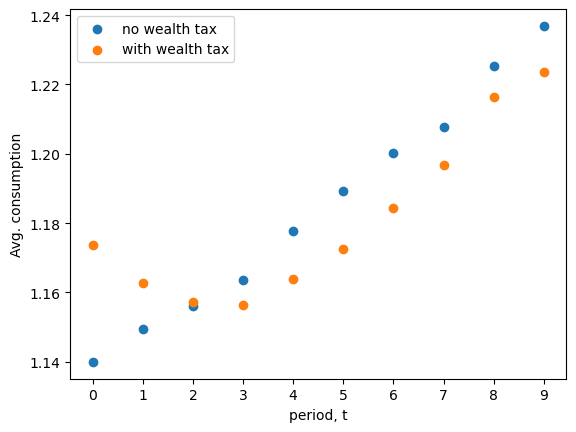

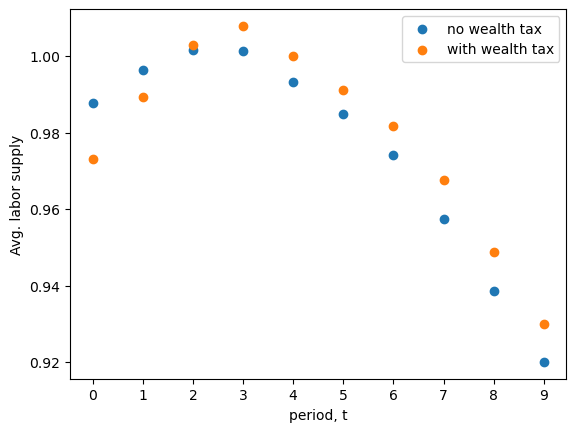

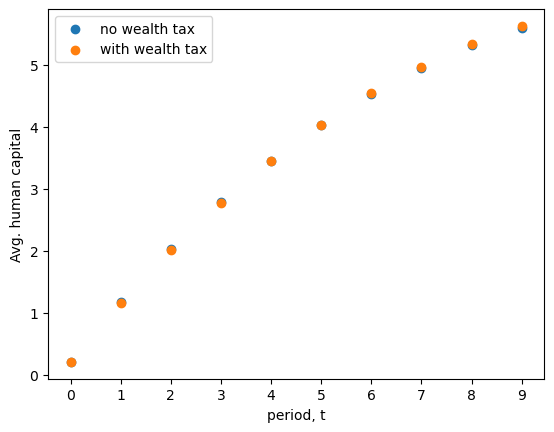

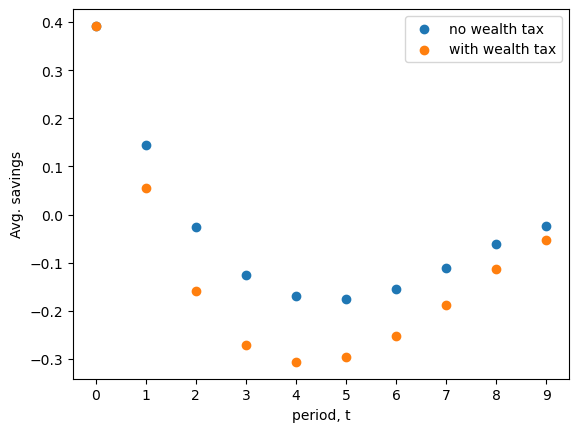

In [19]:
labels = {'c':'consumption', 'h':'labor supply', 'k':'human capital', 'a':'savings'}
for val in ('c','h','k','a'):
    base = np.nanmean(getattr(model_base.sim, val), axis=0)
    tax  = np.nanmean(getattr(model_tax.sim,  val), axis=0)
    fig, ax = plt.subplots()
    ax.scatter(range(len(base)), base, label='no wealth tax',   marker='o')
    ax.scatter(range(len(tax)),  tax,  label='with wealth tax', marker='o')
    ax.set(xlabel='period, t', ylabel=f'Avg. {labels[val]}', xticks=range(model_base.par.simT))
    ax.legend()